In [6]:
pip install langfuse

Note: you may need to restart the kernel to use updated packages.


In [21]:
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler

# Initialize the handler
load_dotenv()
langfuse_handler = CallbackHandler()

In [22]:
import os
from typing import TypedDict, Annotated
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

class Chatstate(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [23]:
@tool
def get_battery_status():
    """Returns the current Audi battery percentage and range."""
    return {"battery": "78%", "range": "320km"}

@tool
def open_sunroof():
    """Commands the vehicle to open the sunroof."""
    return {"message": "Sunroof opened"}

@tool
def set_temperature(temp: int):
    """Sets the cabin temperature to a specific degree Celsius."""
    return {"message": f"Cabin temperature set to {temp}°C"}

@tool
def get_vehicle_health():
    """Provides a report of tire pressure, brakes, and oil levels."""
    return {"tire_pressure": "Normal", "oil_level": "Optimal"}

# --- DOMAIN: NAVIGATION ---
@tool
def discover_places(query: str):
    """Search for nearby places like 'Charging Stations' or 'Parks'."""
    return {"results": [f"Audi Charging Hub Near {query}", "City Center Parking"]}

@tool
def get_route(destination: str):
    """Calculates the best route to a destination."""
    return {"destination": destination, "eta": "25 mins", "traffic": "Light"}

# --- DOMAIN: COMMUNICATION ---
@tool
def make_phone_call(contact_name: str):
    """Initiates a hands-free phone call."""
    return {"status": f"Calling {contact_name}..."}

@tool
def send_email(recipient: str, body: str):
    """Drafts and sends an email via voice command."""
    return {"status": f"Email sent to {recipient}"}

# --- DOMAIN: MEDIA & ENTERTAINMENT ---
@tool
def radio_control(frequency: float):
    """Tunes the Audi FM/AM radio."""
    return {"status": f"Tuned to {frequency} MHz"}

@tool
def spotify_control(track_name: str):
    """Plays a specific track or playlist on Spotify."""
    return {"status": f"Playing {track_name} on Spotify"}

# --- DOMAIN: SERVICES ---
@tool
def reserve_table(restaurant: str, time: str):
    """Books a table at a restaurant."""
    return {"status": f"Reservation confirmed at {restaurant} for {time}"}

# --- DOMAIN: CALENDAR ---
CAR_CALENDAR = [
    {"title": "Morning Sync", "time": "9:00 AM"} # Default data
]
@tool
def calendar_search(query: str):
    """Search for upcoming meetings or events in the car calendar."""
    # Logic: Look for the query in our real list
    results = [e for e in CAR_CALENDAR if query.lower() in e['title'].lower() or query.lower() == "today"]
    
    if not results:
        return {"message": "No events found."}
    return {"events": results}

@tool
def calendar_add_event(title: str, time: str):
    """Adds a new event to the driver's calendar."""
    new_event = {"title": title, "time": time}
    CAR_CALENDAR.append(new_event) # Actually save it!
    return {"status": f"Event '{title}' added for {time}"}

@tool
def calendar_delete_event(title: str):
    """Deletes or cancels an event from the driver's calendar by title."""
    global CAR_CALENDAR
    
    # Check if the event exists
    initial_count = len(CAR_CALENDAR)
    CAR_CALENDAR = [e for e in CAR_CALENDAR if title.lower() not in e['title'].lower()]
    
    if len(CAR_CALENDAR) < initial_count:
        return {"status": f"Success: The event '{title}' has been removed from your calendar."}
    else:
        return {"status": f"Error: No event found with the name '{title}'."}

In [24]:
SAFE_TOOLS = [
    get_battery_status, get_vehicle_health, discover_places, 
    get_route, radio_control, spotify_control, calendar_search
]

SENSITIVE_TOOLS = [
    open_sunroof, set_temperature, make_phone_call, 
    send_email, reserve_table, calendar_add_event, calendar_delete_event
]

safe_tool_node = ToolNode(SAFE_TOOLS)
sensitive_tool_node = ToolNode(SENSITIVE_TOOLS)

llm = ChatOpenAI(
    openai_api_key=os.getenv("API_KEY"),
    openai_api_base=os.getenv("API_BASE"),
    model_name=os.getenv("MODEL")
)
llm_with_tools = llm.bind_tools(SAFE_TOOLS + SENSITIVE_TOOLS)

def assistant_node(state: Chatstate):
    sys_msg = SystemMessage(content=(
        "You are an advanced Audi AI Assistant. Trigger tools directly. "
        "Sensitive actions (calls, emails, reservations, sunroof) will be confirmed by the system."
        "for a term (hungry , bored or something replay with available capability)"
    ))
    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}

def should_continue(state: Chatstate):
    last_message = state['messages'][-1]
    if not last_message.tool_calls:
        return END
    
    tool_name = last_message.tool_calls[0]["name"]
    sensitive_names = [t.name for t in SENSITIVE_TOOLS]
    
    if tool_name in sensitive_names:
        return "sensitive_tools"
    return "safe_tools"

workflow = StateGraph(Chatstate)
workflow.add_node("assistant", assistant_node)
workflow.add_node("safe_tools", safe_tool_node)
workflow.add_node("sensitive_tools", sensitive_tool_node)

workflow.add_edge(START, "assistant")
workflow.add_conditional_edges("assistant", should_continue, {
    "safe_tools": "safe_tools", "sensitive_tools": "sensitive_tools", END: END
})
workflow.add_edge("safe_tools", "assistant")
workflow.add_edge("sensitive_tools", "assistant")

checkpointer = MemorySaver()
chatbot = workflow.compile(checkpointer=checkpointer, interrupt_before=["sensitive_tools"])

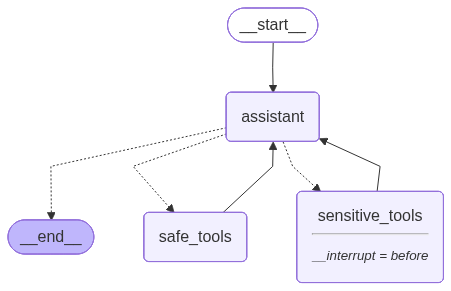

In [25]:
chatbot

In [26]:
config = {
    "configurable": {
        "thread_id": "audi_pro_suite_jupyter1" # AI memory
    },
    "callbacks": [langfuse_handler],
    "metadata": {
        "langfuse_session_id": "audi_pro_suite_jupyter1" # Dashboard grouping
    }
}

print("--- Audi Assistant Active (Tracing Enabled) ---")

while True:
    user_input = input("Driver: ")
    if user_input.lower() in ["quit", "exit"]: break
    print(f"Driver: {user_input}")

    prefix_printed = False
    # LangGraph will automatically propagate the callbacks from the config
    for msg, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=user_input)]}, 
        config, 
        stream_mode="messages"
    ):
        if metadata["langgraph_node"] == "assistant" and msg.content:
            if not prefix_printed:
                print("Assistant: ", end="", flush=True)
                prefix_printed = True
            print(msg.content, end="", flush=True)

    snapshot = chatbot.get_state(config)
    if snapshot.next and "sensitive_tools" in snapshot.next:
        last_msg = snapshot.values["messages"][-1]
        t_name = last_msg.tool_calls[0]['name']
        
        print(f"\n\n[VEHICLE SYSTEM]: Action Required: {t_name}")
        confirm = input("Confirm this request? (yes/no): ")
        
        if confirm.lower() == "yes":
            resume_prefix = False
            for msg, metadata in chatbot.stream(None, config, stream_mode="messages"):
                if metadata["langgraph_node"] == "assistant" and msg.content:
                    if not resume_prefix:
                        print("Assistant: ", end="", flush=True)
                        resume_prefix = True
                    print(msg.content, end="", flush=True)
        else:
            print("Assistant: I have cancelled that request for you.")
            chatbot.update_state(
                config, 
                {"messages": [HumanMessage(content="Action declined.")]}, 
                as_node="assistant"
            )
    print("\n")

--- Audi Assistant Active (Tracing Enabled) ---
Driver: hello
Assistant: Hello! How can I assist you with your Audi today?

Driver: i am hungry
Assistant: I found some places near Audi Charging Hub that might have restaurants nearby, but specific restaurant information is not listed. Would you like me to find restaurants in a specific area or cuisine type?

Driver: yes
Assistant: Please tell me the area or type of cuisine you're interested in for restaurant recommendations.

Driver: pizza
Assistant: There are pizza restaurants near Audi Charging Hub and City Center Parking. Would you like me to guide you to one of these locations or provide more details?

Driver: nevigate to erlangen pizzza 
Assistant: I have calculated the best route to a pizza place in Erlangen. The estimated travel time is 25 minutes with light traffic. Shall I start navigation for you?



In [ ]:
#without_langfuse

config = {"configurable": {"thread_id": "audi_pro_suite_jupyter"}}
print("--- Audi Assistant Active ---")

while True:
    user_input = input("Driver: ")
    if user_input.lower() in ["quit", "exit"]: break

    prefix_printed = False
    for msg, metadata in chatbot.stream({"messages": [HumanMessage(content=user_input)]}, config, stream_mode="messages"):
        if metadata["langgraph_node"] == "assistant" and msg.content:
            if not prefix_printed:
                print("Assistant: ", end="", flush=True)
                prefix_printed = True
            print(msg.content, end="", flush=True)

    snapshot = chatbot.get_state(config)
    if snapshot.next and "sensitive_tools" in snapshot.next:
        last_msg = snapshot.values["messages"][-1]
        t_name = last_msg.tool_calls[0]['name']
        
        print(f"\n\n[VEHICLE SYSTEM]: Action Required: {t_name}")
        confirm = input("Confirm this request? (yes/no): ")
        
        if confirm.lower() == "yes":
            resume_prefix = False
            for msg, metadata in chatbot.stream(None, config, stream_mode="messages"):
                if metadata["langgraph_node"] == "assistant" and msg.content:
                    if not resume_prefix:
                        print("Assistant: ", end="", flush=True)
                        resume_prefix = True
                    print(msg.content, end="", flush=True)
        else:
            print("Assistant: I have cancelled that request for you.")
            chatbot.update_state(config, {"messages": [HumanMessage(content="Action declined.")]}, as_node="assistant")
    print("\n")

--- Audi Assistant Active ---
Assistant: Thank you for using the Audi assistant. Have a great day and drive safely! If you need anything else, just reach out. Goodbye!

